In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gc
gc.collect()

14

In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.9 MB/s eta 0:00:00


In [ ]:
%pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━

Approche générale
Le problème est traité comme une classification binaire (prédire la variable flag). j'ai testé plusieurs modèles, dont LightGBM et AutoGluon, et sélectionné celui qui maximise la métrique ROC-AUC.

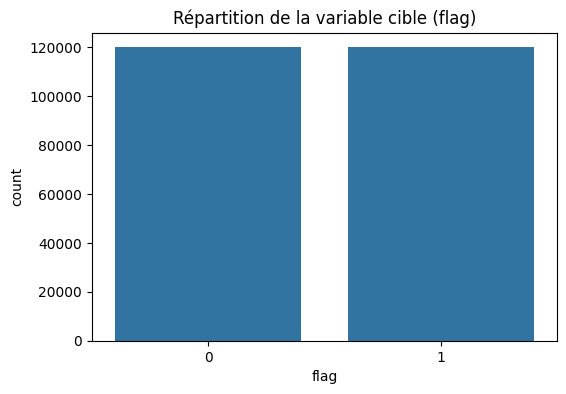

In [ ]:
# Importation des librairies principales utilisées pour l'analyse, la modélisation et la visualisation
import pandas as pd                  # pour manipuler les données sous forme de DataFrame
import numpy as np                   # pour les opérations numériques et les tableaux
import optuna                        # pour l'optimisation automatique des hyperparamètres
from sklearn.model_selection import train_test_split  # pour séparer les données en train et validation
from sklearn.decomposition import PCA               # pour réduire la dimension des données
from lightgbm import LGBMClassifier                # pour entraîner un modèle de gradient boosting
from autogluon.tabular import TabularPredictor     # pour l'entraînement automatique d'ensembles de modèles
from sklearn.metrics import roc_auc_score          # pour calculer la métrique ROC-AUC
import matplotlib.pyplot as plt                    # pour créer des graphiques
import seaborn as sns                              # pour des visualisations statistiques avancées

# ======================================================
# 📂 CHARGEMENT DES DONNÉES
# ======================================================

# Chargement du dataset d'entraînement depuis le fichier parquet
train = pd.read_parquet("/content/drive/MyDrive/train.parquet")

# Création d'un échantillon équilibré de 240k lignes
# On prend 120k lignes de la classe 0 et 120k lignes de la classe 1
df = pd.concat([
    train[train["flag"] == 0].sample(120000, random_state=42),  # échantillon de la classe 0
    train[train["flag"] == 1].sample(120000, random_state=42)   # échantillon de la classe 1
], ignore_index=True)  # réindexe le DataFrame après concaténation

# Définition du nom de la colonne cible
target_col = "flag"   # variable que l'on veut prédire
# Définition du nom de la colonne identifiant unique
id_col = "id_x_rn"    # identifiant de chaque ligne

# Séparation des features (X) et de la cible (y)
X = df.drop(columns=[target_col, id_col], errors="ignore")  # toutes les colonnes sauf la cible et l'id
y = df[target_col]  # variable cible

# ======================================================
# 📊 VISUALISATION DE BASE
# ======================================================

# Création d'une figure pour le graphique
plt.figure(figsize=(6,4))
# Affichage d'un graphique à barres pour voir la répartition des classes de la variable cible
sns.countplot(x=y)
# Ajout d'un titre au graphique
plt.title("Répartition de la variable cible (flag)")
# Affichage du graphique
plt.show()


Ce bloc permet de visualiser la corrélation entre toutes les variables numériques du dataset X. La corrélation mesure comment deux variables évoluent ensemble :

Une corrélation proche de 1 : les variables augmentent ou diminuent ensemble.

Une corrélation proche de -1 : lorsque l’une augmente, l’autre diminue.

Une corrélation proche de 0 : pas de lien linéaire apparent.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


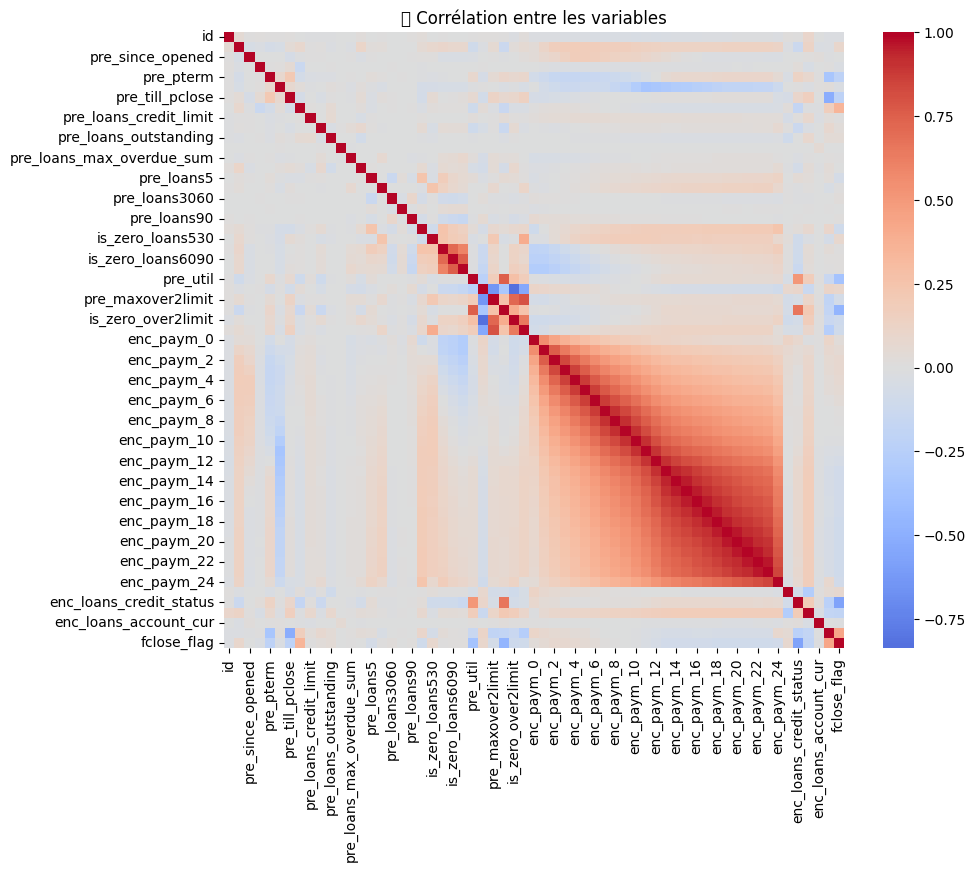

In [ ]:
# Heatmap de corrélation entre variables numériques
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("🔥 Corrélation entre les variables")
plt.show()


In [ ]:
gc.collect()  # force le nettoyage de la mémoire

# ======================================================
# 🧠 1) OPTUNA HYPERPARAMETER SEARCH (LightGBM)
# ======================================================

# Définition de la fonction objectif utilisée par Optuna
# Elle prend un "trial" (essai d'hyperparamètres) et retourne un score à maximiser
def objective(trial):
    """
    Fonction utilisée par Optuna pour tester différentes combinaisons d'hyperparamètres
    et retourner le score ROC-AUC obtenu sur un sous-ensemble de validation.
    """

    # Définition de l'espace de recherche des hyperparamètres
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),            # nombre maximum de feuilles dans l'arbre
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),  # taux d'apprentissage
        "max_depth": trial.suggest_int("max_depth", 3, 10),                # profondeur maximale de l'arbre
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),       # nombre d'arbres
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),           # fraction d'échantillons pour chaque arbre
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0), # fraction de colonnes utilisées
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),           # régularisation L1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),         # régularisation L2
        "random_state": 42,                                                 # graine fixe pour reproductibilité
        "n_jobs": -1,                                                       # utilise tous les cœurs CPU disponibles
    }

    # Split train/validation pour chaque essai (stratifié pour conserver la proportion des classes)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Initialisation du modèle LightGBM avec les hyperparamètres proposés par Optuna
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)       # entraînement rapide sur le sous-ensemble train
    preds = model.predict_proba(X_val)[:, 1]  # probabilité de la classe positive sur le set validation

    return roc_auc_score(y_val, preds)  # retourne le score ROC-AUC pour Optuna (à maximiser)

# Affichage d'un message pour indiquer le début de la recherche d'hyperparamètres
print("🔎 Recherche Optuna en cours (LightGBM)...")

# Création d'une étude Optuna pour maximiser le score
study = optuna.create_study(direction="maximize")

# Lancement de l'optimisation pour 15 essais seulement (rapide)
study.optimize(objective, n_trials=15)

# Récupération des meilleurs hyperparamètres trouvés
best_params = study.best_params
print("✅ Meilleurs paramètres trouvés :", best_params)


[I 2025-11-03 15:12:02,305] A new study created in memory with name: no-name-e5ce2337-5926-4f73-b201-ac9b66882997


🔎 Recherche Optuna en cours (LightGBM)...
[LightGBM] [Info] Number of positive: 96000, number of negative: 96000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.308360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2025-11-03 15:13:02,620] Trial 0 finished with value: 0.6508871102430556 and parameters: {'num_leaves': 113, 'learning_rate': 0.01665950177359044, 'max_depth': 8, 'n_estimators': 325, 'subsample': 0.8611006255973547, 'colsample_bytree': 0.9373946584842074, 'reg_alpha': 0.6271735071626843, 'reg_lambda': 0.37038484666362215}. Best is trial 0 with value: 0.6508871102430556.


[LightGBM] [Info] Number of positive: 96000, number of negative: 96000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

[I 2025-11-03 15:13:29,321] Trial 1 finished with value: 0.6460201493055555 and parameters: {'num_leaves': 126, 'learning_rate': 0.01696040173727698, 'max_depth': 4, 'n_estimators': 773, 'subsample': 0.9966596945718562, 'colsample_bytree': 0.9787904088977243, 'reg_alpha': 0.4027902126231522, 'reg_lambda': 0.5572609114367397}. Best is trial 0 with value: 0.6508871102430556.


...

[LightGBM] [Info] Number of positive: 96000, number of negative: 96000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

[I 2025-11-03 15:17:06,533] Trial 13 finished with value: 0.6539976657986111 and parameters: {'num_leaves': 56, 'learning_rate': 0.06892504454022759, 'max_depth': 8, 'n_estimators': 276, 'subsample': 0.8207968937977123, 'colsample_bytree': 0.7648846065501823, 'reg_alpha': 0.9709913388713065, 'reg_lambda': 0.9824304075832473}. Best is trial 5 with value: 0.6543394236111111.


[LightGBM] [Info] Number of positive: 96000, number of negative: 96000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

[I 2025-11-03 15:17:22,873] Trial 14 finished with value: 0.6541158506944444 and parameters: {'num_leaves': 50, 'learning_rate': 0.07151737267746436, 'max_depth': 8, 'n_estimators': 325, 'subsample': 0.8802222542376686, 'colsample_bytree': 0.7516784297069817, 'reg_alpha': 0.9668694083463695, 'reg_lambda': 0.9607780406999356}. Best is trial 5 with value: 0.6543394236111111.


✅ Meilleurs paramètres trouvés : {'num_leaves': 65, 'learning_rate': 0.07856645548584272, 'max_depth': 10, 'n_estimators': 216, 'subsample': 0.8961654580794934, 'colsample_bytree': 0.7712959884792503, 'reg_alpha': 0.8304905478764385, 'reg_lambda': 0.9903955831105029}


/tmp/ipython-input-2363380493.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


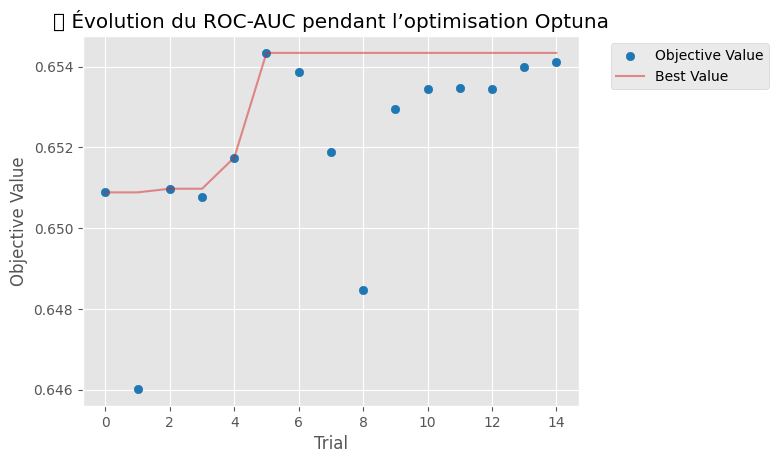

In [ ]:
# Graphique Optuna : évolution du score ROC au fil des essais
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("📈 Évolution du ROC-AUC pendant l’optimisation Optuna")
plt.show()


In [ ]:
# Import du module garbage collector pour libérer de la mémoire inutilisée
import gc
gc.collect()  # force le nettoyage de la mémoire

# ======================================================
# 🔍 2) PCA (RÉDUCTION DE DIMENSION)
# ======================================================

# Affichage d'un message pour indiquer le début de l'application de la PCA
print("Application de la PCA pour réduire le bruit...")

# Initialisation de l'objet PCA
# n_components=0.95 : conserver 95% de la variance des données
# random_state=42 : assure la reproductibilité
pca = PCA(n_components=0.95, random_state=42)

# Application de la PCA sur les features X
# X_pca est un tableau numpy avec les nouvelles composantes principales
X_pca = pca.fit_transform(X)

# Conversion des données réduites en DataFrame pour faciliter les manipulations
df_pca = pd.DataFrame(X_pca)

# Ajout de la colonne cible y au DataFrame réduit
df_pca[target_col] = y.values

# Affichage du nombre de features avant et après réduction
print(f"✅ Données réduites : {X.shape[1]} → {df_pca.shape[1]-1} features")
# Affichage du nombre de lignes (inchangé)
print(f"✅ Données réduites : {X.shape[0]} → {df_pca.shape[0]} lignes")


Application de la PCA pour réduire le bruit...
✅ Données réduites : 61 → 1 features
✅ Données réduites : 240000 → 240000 lignes


In [10]:
gc.collect()
# Split PCA data en train et validation
df_train, df_val = train_test_split(df_pca, test_size=0.2, stratify=df_pca[target_col], random_state=42)

# ======================================================
# 🤖 3) AUTOGluon ENSEMBLE + STACKING
# ======================================================
print("\n🚀 Entraînement AutoGluon (stacking + weighted ensemble)...")

predictor = TabularPredictor(
    label=target_col,              # variable à prédire
    problem_type="binary",         # problème de classification binaire
    eval_metric="roc_auc",         # métrique principale
    path="/content/drive/MyDrive/autogluon_model_advanced"  # dossier de sauvegarde du modèle
).fit(
    train_data=df_train,
    tuning_data=df_val,             # validation explicite
    presets="best_quality",         # corrected preset
    auto_stack=True,                # stacking automatique (ensembles)
    num_stack_levels=3,             # profondeur du stacking
    num_bag_folds=10,               # cross-validation interne
    time_limit=14400,               # temps limite max
    verbosity=3,                    # niveau de log détaillé
    use_bag_holdout=True            # Use tuning_data as holdout for bagging
)

Verbosity: 3 (Detailed Logging)



🚀 Entraînement AutoGluon (stacking + weighted ensemble)...


=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       8.52 GB / 12.67 GB (67.2%)
Disk Space Avail:   58.72 GB / 107.72 GB (54.5%)
Presets specified: ['best_quality']
============ fit kwarg info ============
User Specified kwargs:
{'auto_stack': True,
 'num_bag_folds': 10,
 'num_bag_sets': 1,
 'num_stack_levels': 3,
 'use_bag_holdout': True,
 'verbosity': 3}
Full kwargs:
{'_experimental_dynamic_hyperparameters': False,
 '_feature_generator_kwargs': None,
 '_save_bag_folds': None,
 'ag_args': None,
 'ag_args_ensemble': None,
 'ag_args_fit': None,
 'auto_stack': True,
 'calibrate': 'auto',
 'delay_bag_sets': False,
 'ds_args': {'clean_up_fits': True,
             'detection_time_frac': 0.25,
             'enable_callbacks': False,
             'enable_ray_logging': Tr

                      model  score_val eval_metric  pred_time_val      fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0       WeightedEnsemble_L5   0.786729     roc_auc     388.744401   8841.659606                0.013271           9.971008            5       True         42
1       WeightedEnsemble_L3   0.786604     roc_auc     332.401374   6326.891767                0.011411           2.630653            3       True         24
2    NeuralNetFastAI_BAG_L2   0.786361     roc_auc     271.375066   5670.695662                9.596669        1295.698411            2       True         20
3         LightGBMXT_BAG_L2   0.786001     roc_auc     300.852935   4609.990014               39.074538         234.992763            2       True         13
4       WeightedEnsemble_L4   0.785768     roc_auc     397.354813   9492.346904                0.022854           2.854823            4       True         36
5    NeuralNetFastAI_BAG_L3   0.785691     roc_auc  

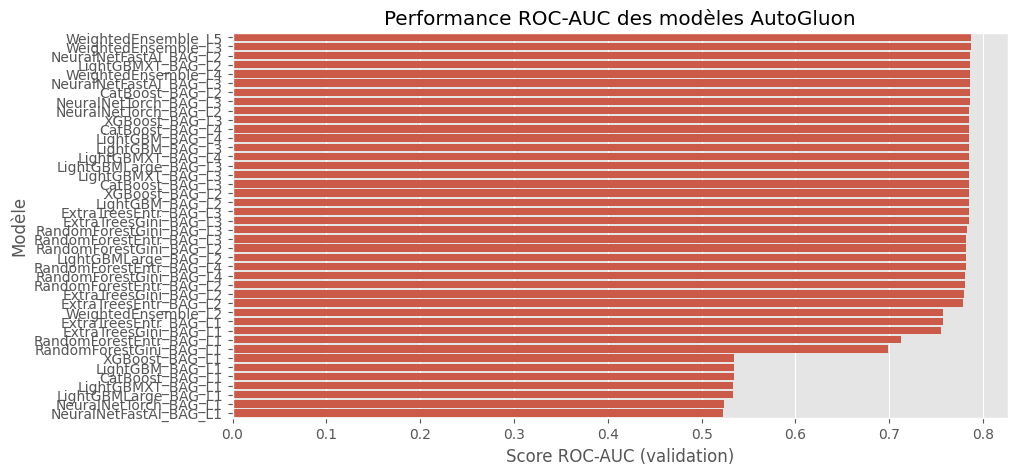

In [11]:
# Nettoyage de la mémoire pour libérer des ressources inutilisées
gc.collect()

# ======================================================
# 📈 ÉVALUATION
# ======================================================

# Génération du leaderboard AutoGluon
# Affiche les modèles entraînés et leurs performances triés selon la métrique choisie (ROC-AUC)
leaderboard = predictor.leaderboard(silent=False)

# Affichage dans la console des meilleurs modèles
print("\n Meilleurs modèles AutoGluon (triés par ROC-AUC) :")
print(leaderboard.head())  # affiche les 5 premiers modèles du leaderboard

# Visualisation graphique des performances des modèles
plt.figure(figsize=(10, 5))  # taille de la figure
sns.barplot(
    x="score_val",  # score ROC-AUC sur les données de validation
    y="model",      # nom du modèle
    data=leaderboard.sort_values("score_val", ascending=False)  # tri des modèles par score décroissant
)
plt.title("Performance ROC-AUC des modèles AutoGluon")  # titre du graphique
plt.xlabel("Score ROC-AUC (validation)")               # label axe X
plt.ylabel("Modèle")                                  # label axe Y
plt.show()  # affichage du graphique


Loading: /content/drive/MyDrive/autogluon_model_advanced/models/CatBoost_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/ExtraTreesEntr_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/ExtraTreesGini_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/LightGBMLarge_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/LightGBMXT_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/LightGBM_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/NeuralNetFastAI_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/NeuralNetTorch_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/RandomForestEntr_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_advanced/models/RandomForestGini_BAG_L1/model.pkl
Loading: /content/drive/MyDrive/autogluon_model_adva


✅ Fichier final sauvegardé : /content/drive/MyDrive/submission_autogluon_advanced_Michel.parquet


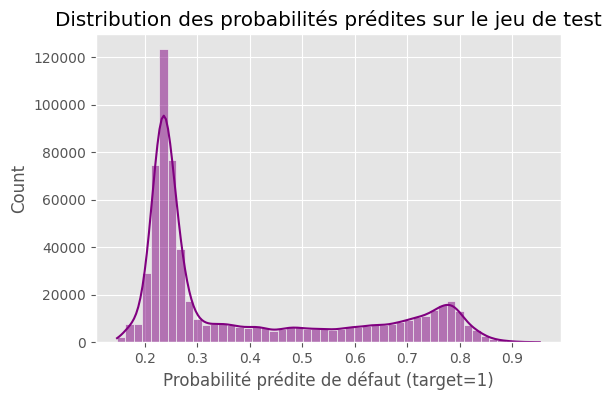

In [12]:
# ======================================================
# 🔮 PRÉDICTION TEST
# ======================================================
test = pd.read_parquet("/content/drive/MyDrive/test.parquet")  # données de test réelles (sans flag)

# Apply the same PCA transformation to the test data
test_pca = pca.transform(test.drop(columns=[id_col], errors='ignore'))
test_pca_df = pd.DataFrame(test_pca, columns=df_pca.drop(columns=[target_col]).columns)


preds = predictor.predict_proba(test_pca_df)  # prédiction des probabilités
if isinstance(preds, pd.DataFrame):
    preds = preds[1]  # on garde la probabilité de la classe positive

# Construction du fichier de soumission final
submission = pd.DataFrame({
    "id": test[id_col],
    "target": preds
})

output_path = "/content/drive/MyDrive/submission_autogluon_advanced_Michel.parquet"
submission.to_parquet(output_path, index=False)

print(f"\n✅ Fichier final sauvegardé : {output_path}")


# Visualisation rapide de la distribution des probabilités prédites
plt.figure(figsize=(6,4))
sns.histplot(preds, bins=50, kde=True, color="purple")
plt.title("Distribution des probabilités prédites sur le jeu de test")
plt.xlabel("Probabilité prédite de défaut (target=1)")
plt.show()

In [13]:
# 📦 Export des dépendances pour Datatour
!pip freeze > requirements.txt
print("✅ Fichier requirements.txt généré avec succès !")

✅ Fichier requirements.txt généré avec succès !
